# <u><center> COVID-19 Global Data Analysis </center></u>

## Objective

The goal of this project is to analyze global COVID-19 trends across continents using publicly available data.
We explore:
* Data structure and quality
* Geographical distribution of cases
* Economic and development impact
* Feature engineering
* Visual insights

This analysis helps understand how COVID-19 affected different continents and its relationship with GDP and development index.

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

### Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/SR1608/Datasets/main/covid-data.csv"
df = pd.read_csv(url)

df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,31/12/19,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,01/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,02/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,03/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,04/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


##### <u>Insight :</u>
* The dataset contains COVID statistics for multiple countries and continents with economic indicators.

### High Level Data Understanding

#### -> Dataset Shape

In [3]:
df.shape

(57394, 49)

* <span style="background-color:yellow">There are 57394 rows and 49 columns.</span>

#### -> Data Types

In [4]:
df.dtypes

iso_code                               object
continent                              object
location                               object
date                                   object
total_cases                           float64
new_cases                             float64
new_cases_smoothed                    float64
total_deaths                          float64
new_deaths                            float64
new_deaths_smoothed                   float64
total_cases_per_million               float64
new_cases_per_million                 float64
new_cases_smoothed_per_million        float64
total_deaths_per_million              float64
new_deaths_per_million                float64
new_deaths_smoothed_per_million       float64
reproduction_rate                     float64
icu_patients                          float64
icu_patients_per_million              float64
hosp_patients                         float64
hosp_patients_per_million             float64
weekly_icu_admissions             

#### -> Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57394 entries, 0 to 57393
Data columns (total 49 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            57071 non-null  object 
 1   continent                           56748 non-null  object 
 2   location                            57394 non-null  object 
 3   date                                57394 non-null  object 
 4   total_cases                         53758 non-null  float64
 5   new_cases                           56465 non-null  float64
 6   new_cases_smoothed                  55652 non-null  float64
 7   total_deaths                        44368 non-null  float64
 8   new_deaths                          56465 non-null  float64
 9   new_deaths_smoothed                 55652 non-null  float64
 10  total_cases_per_million             53471 non-null  float64
 11  new_cases_per_million               56401

#### -> Statistical Summary

In [6]:
df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
count,5.375800e+04,56465.000000,55652.000000,4.436800e+04,56465.000000,55652.000000,53471.000000,56401.000000,55587.000000,44096.000000,...,50367.000000,33571.000000,51013.000000,52881.000000,39669.000000,39156.000000,24176.000000,45936.000000,56336.000000,49247.000000
mean,1.677974e+05,1953.576941,1920.431953,6.858639e+03,47.054317,46.835439,3139.099982,39.344804,38.403211,95.335293,...,20620.172071,12.435453,252.646642,8.070269,10.741569,32.642686,52.089636,3.089724,73.937780,0.722223
std,1.693038e+06,18269.650340,17777.391785,5.578081e+04,390.853776,378.272794,6183.455260,133.985155,101.649441,180.721699,...,20310.999832,19.427924,117.522344,4.189605,10.470743,13.453566,31.645306,2.513193,7.397016,0.153261
min,1.000000e+00,-8261.000000,-552.000000,1.000000e+00,-1918.000000,-232.143000,0.001000,-2212.545000,-269.978000,0.000000,...,661.240000,0.100000,79.370000,0.990000,0.100000,7.700000,1.188000,0.100000,53.280000,0.354000
25%,1.800000e+02,0.000000,0.857000,1.300000e+01,0.000000,0.000000,90.033000,0.000000,0.260000,3.977750,...,5321.444000,0.500000,156.139000,5.310000,1.900000,21.400000,21.222000,1.300000,69.870000,0.601000
50%,2.070000e+03,14.000000,19.429000,8.400000e+01,0.000000,0.286000,593.663000,2.194000,3.863000,20.383000,...,13913.839000,2.000000,238.339000,7.110000,6.400000,31.400000,52.232000,2.500000,75.345000,0.752000
75%,2.235675e+04,235.000000,245.286000,7.270000e+02,4.000000,4.000000,3487.050000,25.941000,29.678500,90.571250,...,31400.840000,18.100000,318.991000,10.390000,19.600000,40.900000,83.741000,4.200000,79.380000,0.847000
max,5.515465e+07,646281.000000,584981.857000,1.328537e+06,10600.000000,9027.714000,76541.772000,8652.658000,2472.188000,1248.014000,...,116935.600000,77.600000,724.417000,30.530000,44.000000,78.100000,98.999000,13.800000,86.750000,0.953000


##### <u>Insight :</u>
* Large variance in total cases and deaths.
* GDP and development index vary significantly across regions.

### Low Level Data Understanding

#### -> Unique Locations

In [7]:
df['location'].nunique()

216

* <span style="background-color:yellow">There are 216 countries/regions present.</span>

#### -> Continent Frequency

In [8]:
df['continent'].value_counts()

continent
Europe           14828
Africa           13637
Asia             13528
North America     9116
South America     3404
Oceania           2235
Name: count, dtype: int64

##### <u>Insight :</u>
* <span style="background-color:yellow">The Europe continent has the most data records i.e. 14828.</span>
* The Oceania continent has the least data records i.e. 2235.

#### -> Maximum & Mean Total Cases

In [9]:
df['total_cases'].agg(['max','mean'])

max     5.515465e+07
mean    1.677974e+05
Name: total_cases, dtype: float64

#### -> Quartiles of Total Deaths

In [10]:
df['total_deaths'].quantile([0.25,0.50,0.75])

0.25     13.0
0.50     84.0
0.75    727.0
Name: total_deaths, dtype: float64

#### -> Max Human Development Index by Continent

In [11]:
df.groupby('continent')['human_development_index'].max()

continent
Africa           0.797
Asia             0.933
Europe           0.953
North America    0.926
Oceania          0.939
South America    0.843
Name: human_development_index, dtype: float64

#### -> Minimum GDP Per Capita by Continent

In [12]:
df.groupby('continent')['gdp_per_capita'].min()

continent
Africa            661.240
Asia             1479.147
Europe           5189.972
North America    1653.173
Oceania          2205.923
South America    6885.829
Name: gdp_per_capita, dtype: float64

### Column Filtering

In [13]:
df = df[['continent','location','date','total_cases',
         'total_deaths','gdp_per_capita',
         'human_development_index']]
df.head()

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index
0,Asia,Afghanistan,31/12/19,NaN,NaN,1803.987,0.498
1,Asia,Afghanistan,01/01/20,NaN,NaN,1803.987,0.498
2,Asia,Afghanistan,02/01/20,NaN,NaN,1803.987,0.498
3,Asia,Afghanistan,03/01/20,NaN,NaN,1803.987,0.498
4,Asia,Afghanistan,04/01/20,NaN,NaN,1803.987,0.498


### Data Cleaning

#### -> Remove Duplicates

In [14]:
df.drop_duplicates(inplace=True)

#### -> Missing Values Check

In [15]:
df.isnull().sum()

continent                    646
location                       0
date                           0
total_cases                 3636
total_deaths               13026
gdp_per_capita              7027
human_development_index     8147
dtype: int64

#### -> Remove Rows with Missing Continent

In [ ]:
df.dropna(subset=['continent'], inplace=True)

#### -> Fill Remaining Missing Values with Zero

In [16]:
df.fillna(0, inplace=True)

### Date Handling

#### -> Convert Date Column

In [17]:
df['date'] = pd.to_datetime(df['date'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_18460\3532345252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


#### -> Extract Month Feature

In [18]:
df['month'] = df['date'].dt.month
df.head()

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index,month
0,Asia,Afghanistan,2019-12-31,0.0,0.0,1803.987,0.498,12
1,Asia,Afghanistan,2020-01-01,0.0,0.0,1803.987,0.498,1
2,Asia,Afghanistan,2020-02-01,0.0,0.0,1803.987,0.498,2
3,Asia,Afghanistan,2020-03-01,0.0,0.0,1803.987,0.498,3
4,Asia,Afghanistan,2020-04-01,0.0,0.0,1803.987,0.498,4


* Month helps analyze seasonal trends if needed later.

### Data Aggregation

#### -> Maximum Values by Continent

In [19]:
df_groupby = df.groupby('continent').max().reset_index()
df_groupby

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index,month
0,0,World,2020-12-11,55154651.0,1328537.0,15469.207,0.000,12
1,Africa,Zimbabwe,2020-12-11,752269.0,20314.0,26382.287,0.797,12
2,Asia,Yemen,2020-12-11,8874290.0,130519.0,116935.600,0.933,12
3,Europe,Vatican,2020-12-11,1991233.0,52147.0,94277.965,0.953,12
4,North America,United States Virgin Islands,2020-12-11,11205486.0,247220.0,54225.446,0.926,12
5,Oceania,Wallis and Futuna,2020-12-11,27750.0,907.0,44648.710,0.939,12
6,South America,Venezuela,2020-12-11,5876464.0,166014.0,22767.037,0.843,12


### Feature Engineering

#### -> Mortality Ratio

In [20]:
df_groupby['total_deaths_to_total_cases'] = (
    df_groupby['total_deaths'] / df_groupby['total_cases']
)

df_groupby[['continent','total_deaths_to_total_cases']]

,continent,total_deaths_to_total_cases
0,0,0.024087
1,Africa,0.027004
2,Asia,0.014708
3,Europe,0.026188
4,North America,0.022062
5,Oceania,0.032685
6,South America,0.028251


* Higher ratio indicates higher mortality severity.

### Data Visualization & Insights

#### 1. GDP Distribution

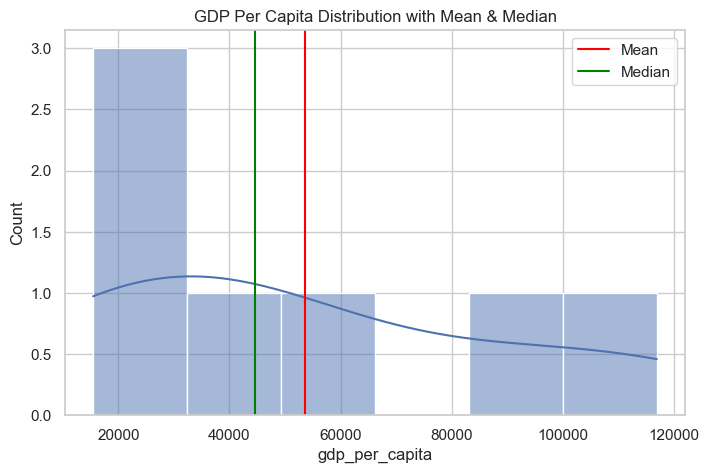

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df_groupby['gdp_per_capita'], bins=6, kde=True)

plt.axvline(df_groupby['gdp_per_capita'].mean(), color='red', label='Mean')
plt.axvline(df_groupby['gdp_per_capita'].median(), color='green', label='Median')

plt.legend()
plt.title("GDP Per Capita Distribution with Mean & Median")
plt.show()

##### <u>Insight :</u>
* Most continents have GDP per capita between $20k–$60k, indicating moderate economic strength.
* The distribution is right-skewed, meaning only a few continents have extremely high GDP.
* Large spread suggests economic inequality across continents
* Higher GDP may influence:
       better healthcare,
       more testing,
       better reporting of COVID cases.

In [27]:
print("Mean GDP:", df_groupby['gdp_per_capita'].mean())
print("Median GDP:", df_groupby['gdp_per_capita'].median())
print("Std Dev:", df_groupby['gdp_per_capita'].std())

Mean GDP: 53529.46457142858
Median GDP: 44648.71
Std Dev: 38496.77453080981


<span style="background-color:yellow">The GDP per capita distribution is positively skewed. Most continents fall in the mid-income range, while only a few show very high GDP. This suggests economic disparity, which may affect healthcare infrastructure and COVID outcomes.</span>

#### 2. GDP vs Total Cases

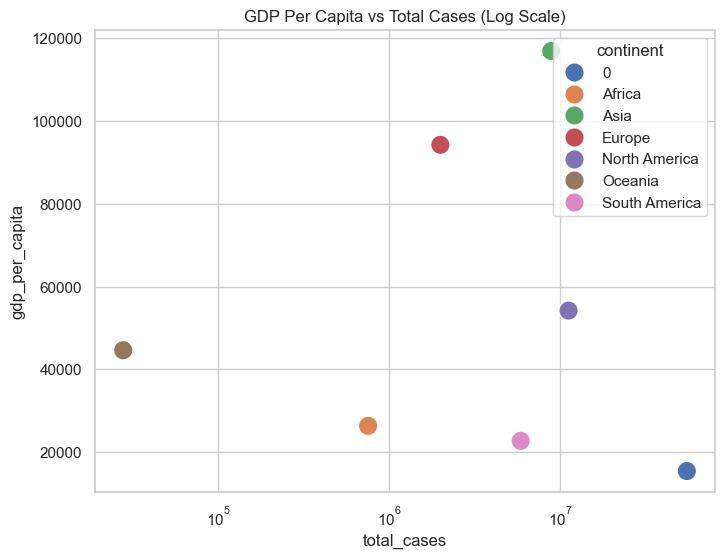

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_groupby,
    x='total_cases',
    y='gdp_per_capita',
    hue='continent',
    s=200
)

plt.xscale('log')   # makes spread easier to see
plt.title("GDP Per Capita vs Total Cases (Log Scale)")
plt.show()

##### <u>Insight :</u>
* GDP per capita does not show a strong linear relationship with total COVID cases.
* Developed continents tend to report more cases due to better healthcare and testing systems.
* Lower GDP regions may under-report cases due to limited resources.
* Population size also significantly impacts total cases.

In [31]:
df_groupby[['total_cases','gdp_per_capita']].corr()

,total_cases,gdp_per_capita
total_cases,1.000000,-0.366214
gdp_per_capita,-0.366214,1.000000


<span style="background-color:yellow">The scatter plot shows no strong correlation between GDP and total cases. Developed regions tend to report more cases due to better testing infrastructure, while lower GDP regions may show fewer reported cases because of under-reporting. Hence, GDP alone does not determine case count.</span>

#### 3. Pairplot – Multivariate Analysis

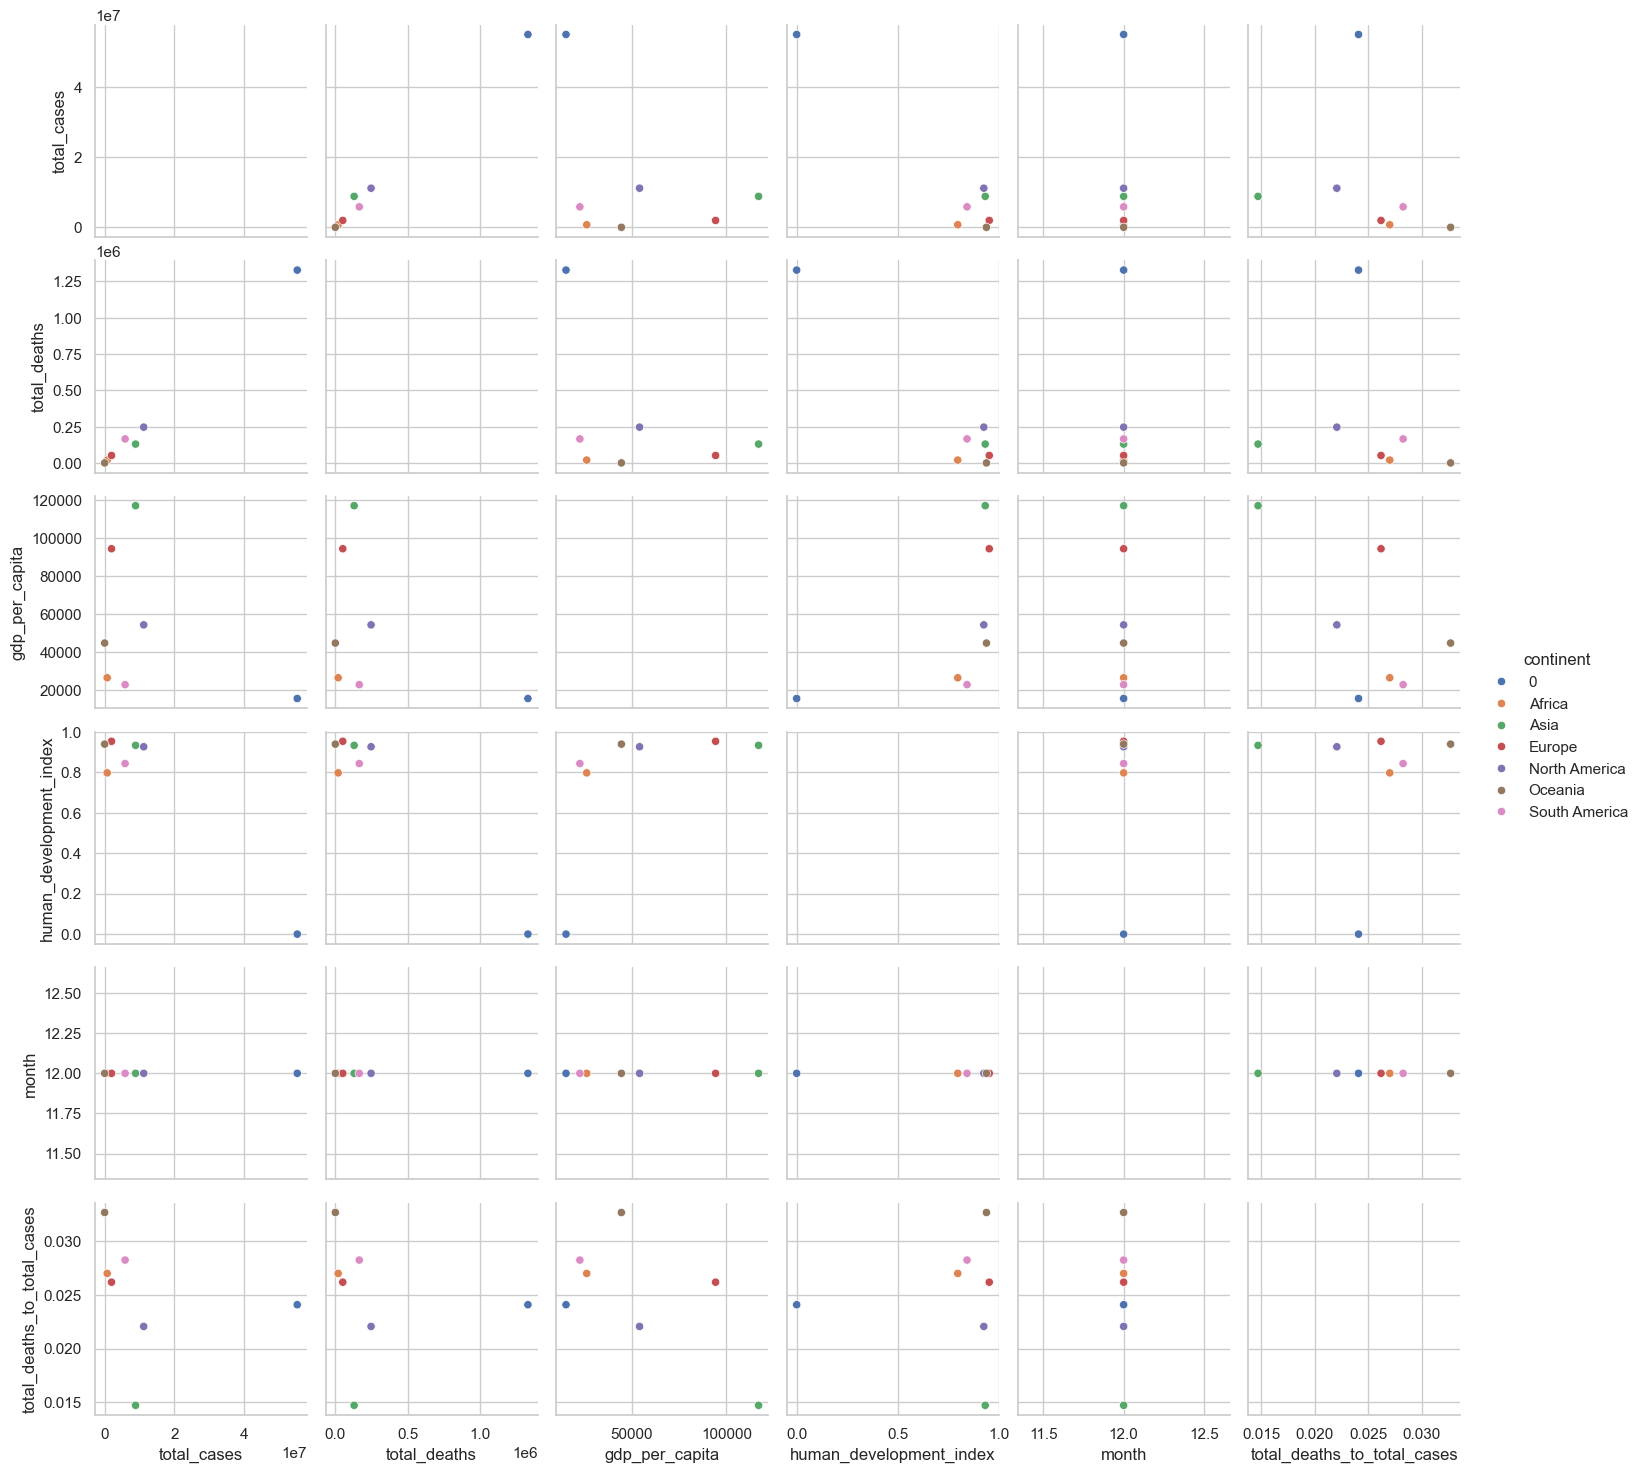

In [23]:
sns.pairplot(df_groupby, hue='continent')
plt.show()

##### <u>Insight :</u>
* A strong positive relationship exists between total cases and total deaths.
* GDP per capita and Human Development Index show high positive correlation, indicating economic prosperity improves quality of life.
* No strong relationship between GDP and total COVID cases was observed, suggesting cases depend more on population density and testing capacity.
* Higher HDI continents tend to show lower death ratios due to better healthcare systems.
* Continents form distinct clusters based on economic and health indicators.

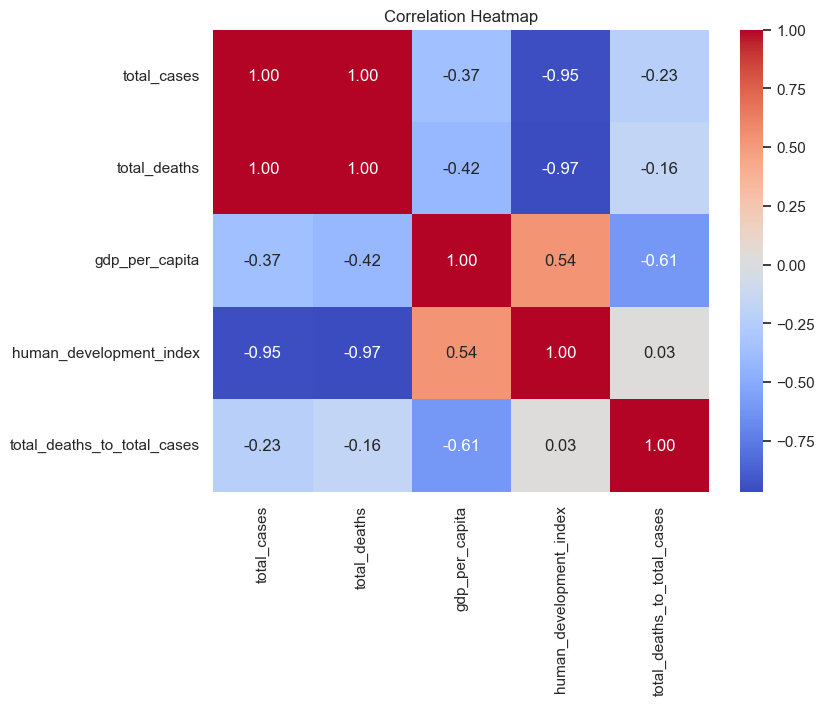

In [36]:
cols = [
    'total_cases',
    'total_deaths',
    'gdp_per_capita',
    'human_development_index',
    'total_deaths_to_total_cases'
]

corr = df_groupby[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

##### <u>Insights :</u>
* A perfect positive correlation exists between total cases and total deaths, indicating that higher infection counts naturally lead to higher fatalities.
* GDP per capita shows a moderate positive correlation with Human Development Index, confirming that economic strength improves overall development.
* <span style="background-color:yellow">COVID spread is influenced more by: population size, density, mobility, testing/reporting policies,
Not GDP alone.</span>
* GDP per capita shows a weak negative correlation with total cases, indicating that economic status alone does not determine infection spread.
* The strong negative correlation is influenced by population size and aggregation at the continent level rather than indicating that higher development causes fewer infections.
* <span style="background-color:yellow">Better healthcare systems, ICU capacity, and early intervention reduce fatality risk.</span>
* A moderate negative correlation between GDP per capita and mortality ratio suggests that economically stronger regions experience lower fatality rates.
* Human Development Index shows no significant correlation with death ratio, indicating the influence of multiple external factors.

<span style="background-color:yellow">Yes, HDI showed a strong negative correlation with total cases, but this is due to continent-level aggregation and population size effects, not because development reduces infections.</span>

#### 4. Total Cases by Continent

In [ ]:
df.dropna(subset=['continent'], inplace=True)
df.fillna(0, inplace=True)

In [39]:
df_groupby = df_groupby[df_groupby['continent'] != 0]

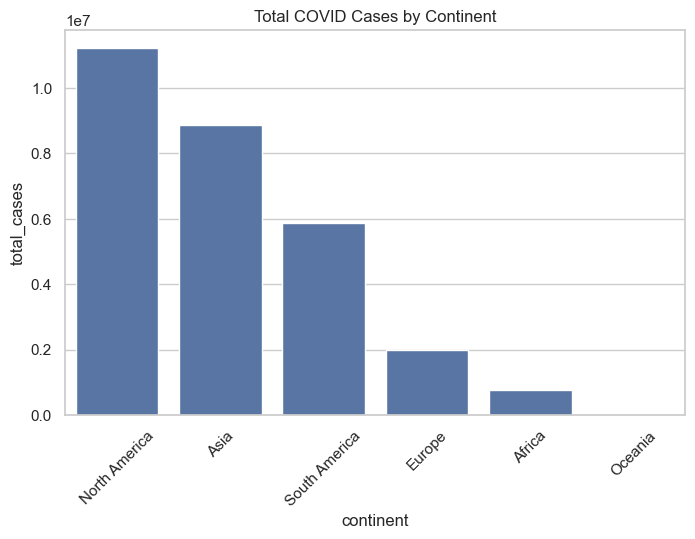

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='continent',
    y='total_cases',
    data=df_groupby.sort_values('total_cases', ascending=False)
)

plt.title("Total COVID Cases by Continent")
plt.xticks(rotation=45)
plt.show()

##### <u>Insight :</u>
* The bar plot indicates that North America recorded the highest number of COVID-19 cases, followed by Asia and South America. These regions have large populations and strong testing/reporting systems, resulting in higher confirmed counts. Europe shows moderate cases, likely due to effective control measures. Africa and Oceania report fewer cases, which may reflect lower population density, geographic isolation, or under-reporting. Overall, population size and testing infrastructure appear to influence reported case counts more than economic status alone.

<span style="background-color:yellow">North America and Asia have the highest cases mainly due to population and testing coverage. Africa and Oceania show fewer reported cases, possibly due to under-reporting or lower density. Hence, total cases depend more on population and reporting systems than GDP alone.</span>

#### 5. Mortality Ratio by Continent (Extra Insight)

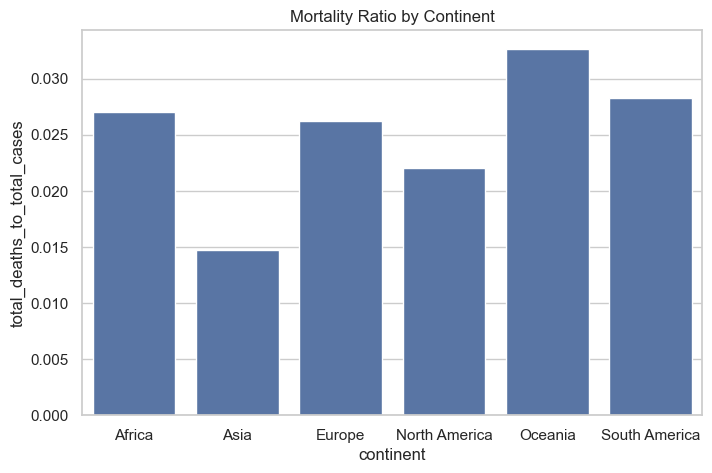

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(x='continent',
            y='total_deaths_to_total_cases',
            data=df_groupby)
plt.title("Mortality Ratio by Continent")
plt.show()

##### <u>Insight :</u>
* Mortality analysis reveals that Oceania and South America exhibit the highest death-to-case ratios, possibly due to smaller population sizes and healthcare constraints. Asia shows the lowest mortality, suggesting effective containment strategies and better recovery outcomes. North America and Europe demonstrate moderate fatality rates supported by advanced healthcare systems. Overall, mortality appears more influenced by healthcare capacity and policy response than by total case counts.

<span style="background-color:yellow">While North America and Asia had high case counts, Asia shows the lowest mortality ratio, indicating effective healthcare and control measures. Mortality depends more on healthcare infrastructure and response rather than just total infections.</span>

### Save Processed Data

In [42]:
df_groupby.to_csv("df_groupby.csv", index=False)

## <u>Final Insight & Conclusion</u>

In summary, the exploratory analysis highlights that COVID-19 spread is largely influenced by population size and testing infrastructure, while mortality is more closely linked to healthcare capacity and development levels. Continents with stronger healthcare systems demonstrate lower fatality rates despite higher case counts. These insights emphasize the importance of preparedness, medical infrastructure, and timely intervention in managing global health crises.